In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import uproot
import sys
import seaborn as sns
from tqdm import tqdm
import networkx as nx

import atlasify as atl
from particle import Particle
atl.ATLAS = "ColliderML"

sys.path.append("/global/cfs/cdirs/m4958/usr/danieltm/ColliderML/software/OtherLibraries/pyedm4hep")
from pyedm4hep import EDM4hepEvent

## Roadmap

1. Load an edm4hep file
2. Load the particles and tracker hits


## Loading

In [2]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [ ]:
file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v3/runs/all/edm4hep.root"
event = EDM4hepEvent(file_path, event_index=0, detector_params=detector_params)
particles = event.get_particles_df()
hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_contributions_df()
daughters = event.get_daughters_df()

Loading event 0 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v1/runs/all/edm4hep.root...
  Loaded 1 particles.
  Loaded 11 tracker hits.
  Loaded 85 calo hits and 187 contributions.


## Plotting

In [45]:
tracker_reco_particles = particles[particles.index.isin(hits.particle_id)]

In [46]:
tracker_reco_particles.columns

Index(['PDG', 'generatorStatus', 'simulatorStatus', 'charge', 'time', 'mass',
       'vx', 'vy', 'vz', 'px', 'py', 'pz', 'endpoint_x', 'endpoint_y',
       'endpoint_z', 'parents_begin', 'parents_end', 'daughters_begin',
       'daughters_end', 'pt', 'p', 'eta', 'phi', 'vr', 'endpoint_r', 'energy',
       'kinetic_energy', 'num_hits', 'created_in_simulation',
       'created_inside_tracker', 'ended_inside_tracker', 'backscatter'],
      dtype='object')

<Axes: >

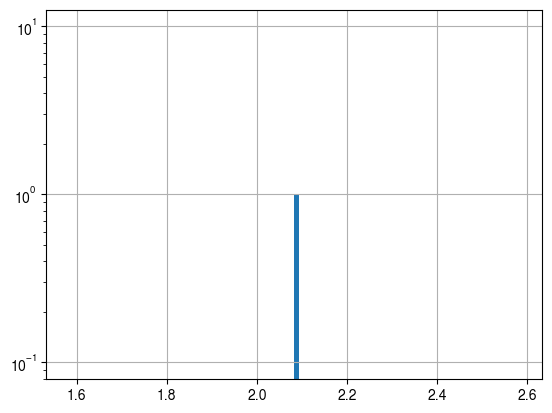

In [16]:
tracker_reco_particles.pt.hist(bins=100, log=True)
# log x

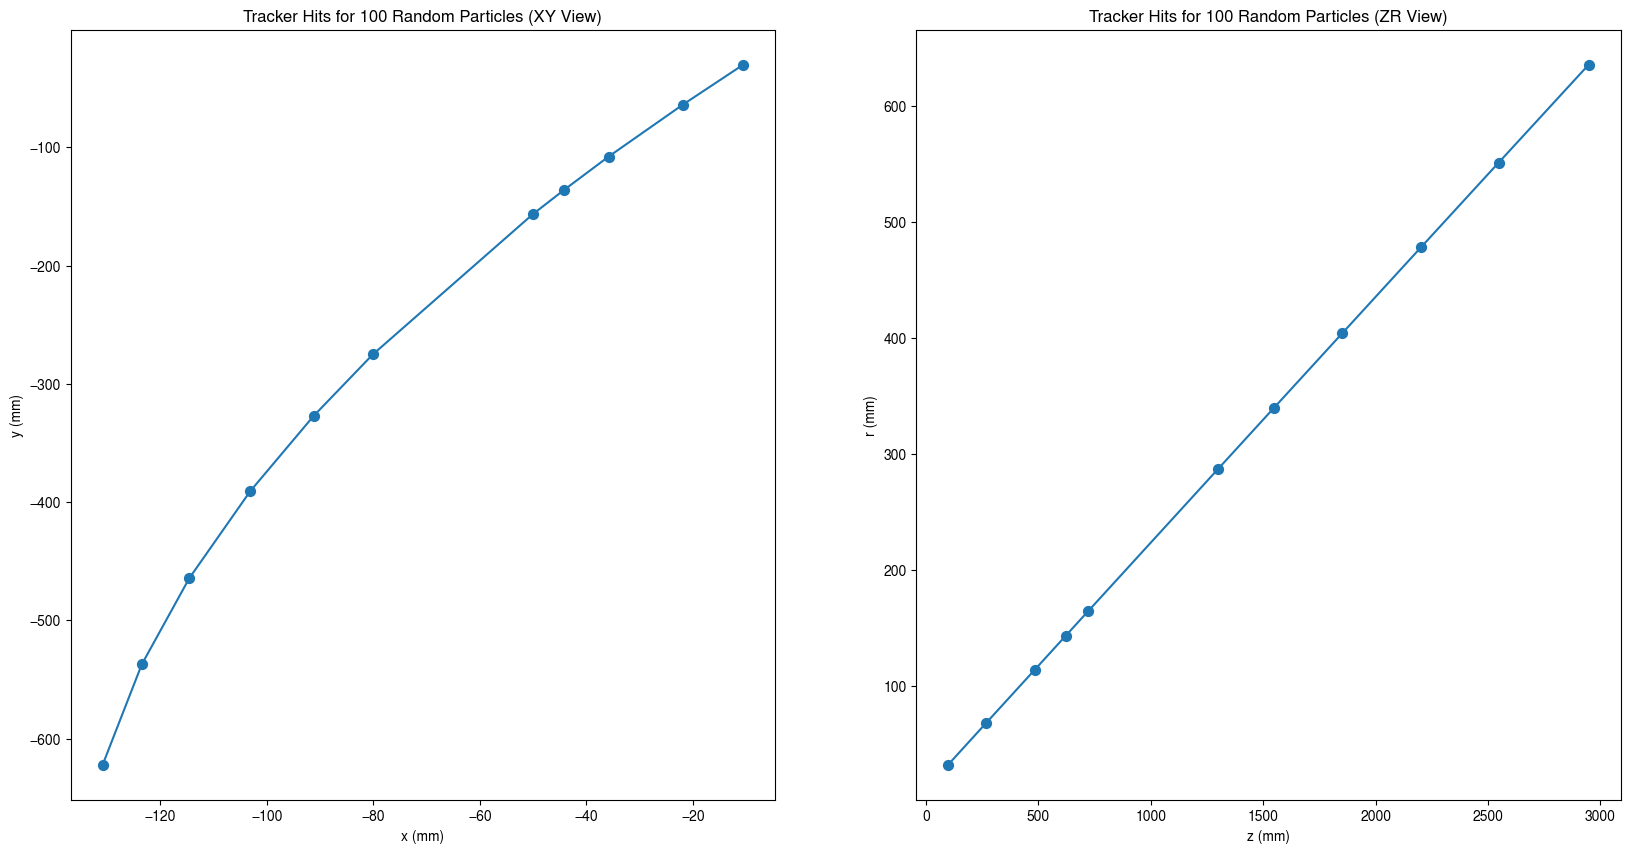

In [48]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Select 50 random particles
sample_particles = tracker_reco_particles.sample(1, random_state=42)

# Select all hits for the selected particles
sample_hits = hits[hits['particle_id'].isin(sample_particles.index)]

# Plot the hits, colored by particle id
for particle_id in sample_particles.index:
    particle_hits = sample_hits[sample_hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

## Loading

In [53]:
# Define conservative detector parameters
detector_params = {
    'tracking_radius': 1080,    # in mm
    'tracking_z_max': 3030,     # in mm
    'energy_threshold': 0.     # in GeV
}

In [77]:
file_path = "/pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v2/runs/all/edm4hep.root"
event = EDM4hepEvent(file_path, event_index=20000, detector_params=detector_params)
particles = event.get_particles_df()
hits = event.get_tracker_hits_df()
calo_hits = event.get_calo_contributions_df()
daughters = event.get_daughters_df()

Error: Event index 20000 is out of bounds (0-19999).


ValueError: Failed to load event 20000 from /pscratch/sd/d/danieltm/ColliderML/simulation/single_particle_pilot/muon_10GeV/v2/runs/all/edm4hep.root.

## Plotting

In [70]:
tracker_reco_particles = particles[particles.index.isin(hits.particle_id)]

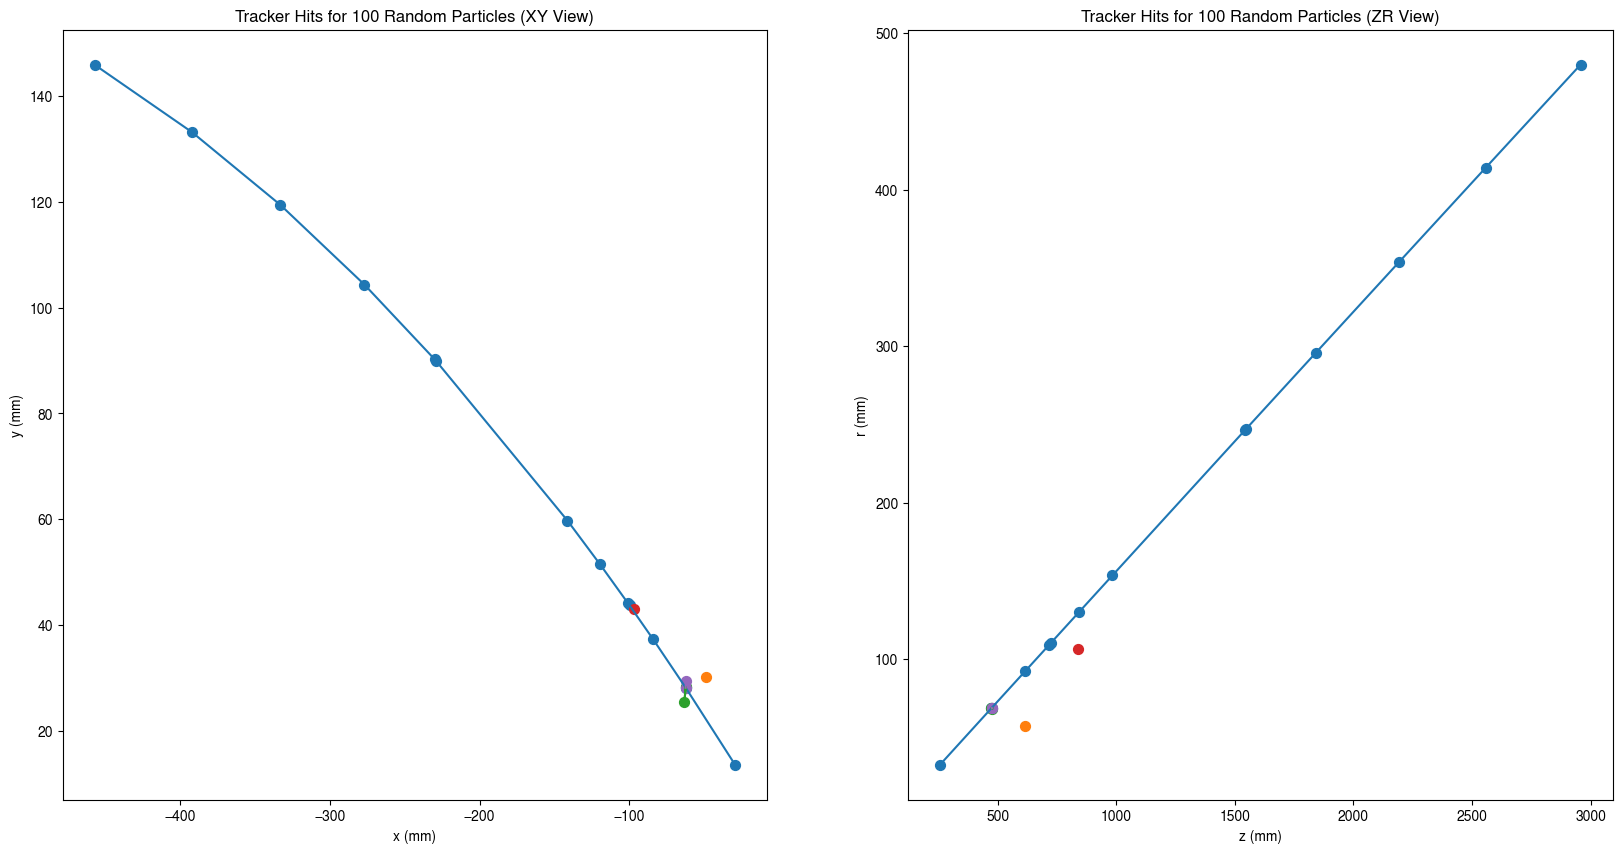

In [68]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in tracker_reco_particles.index:
    particle_hits = hits[hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()

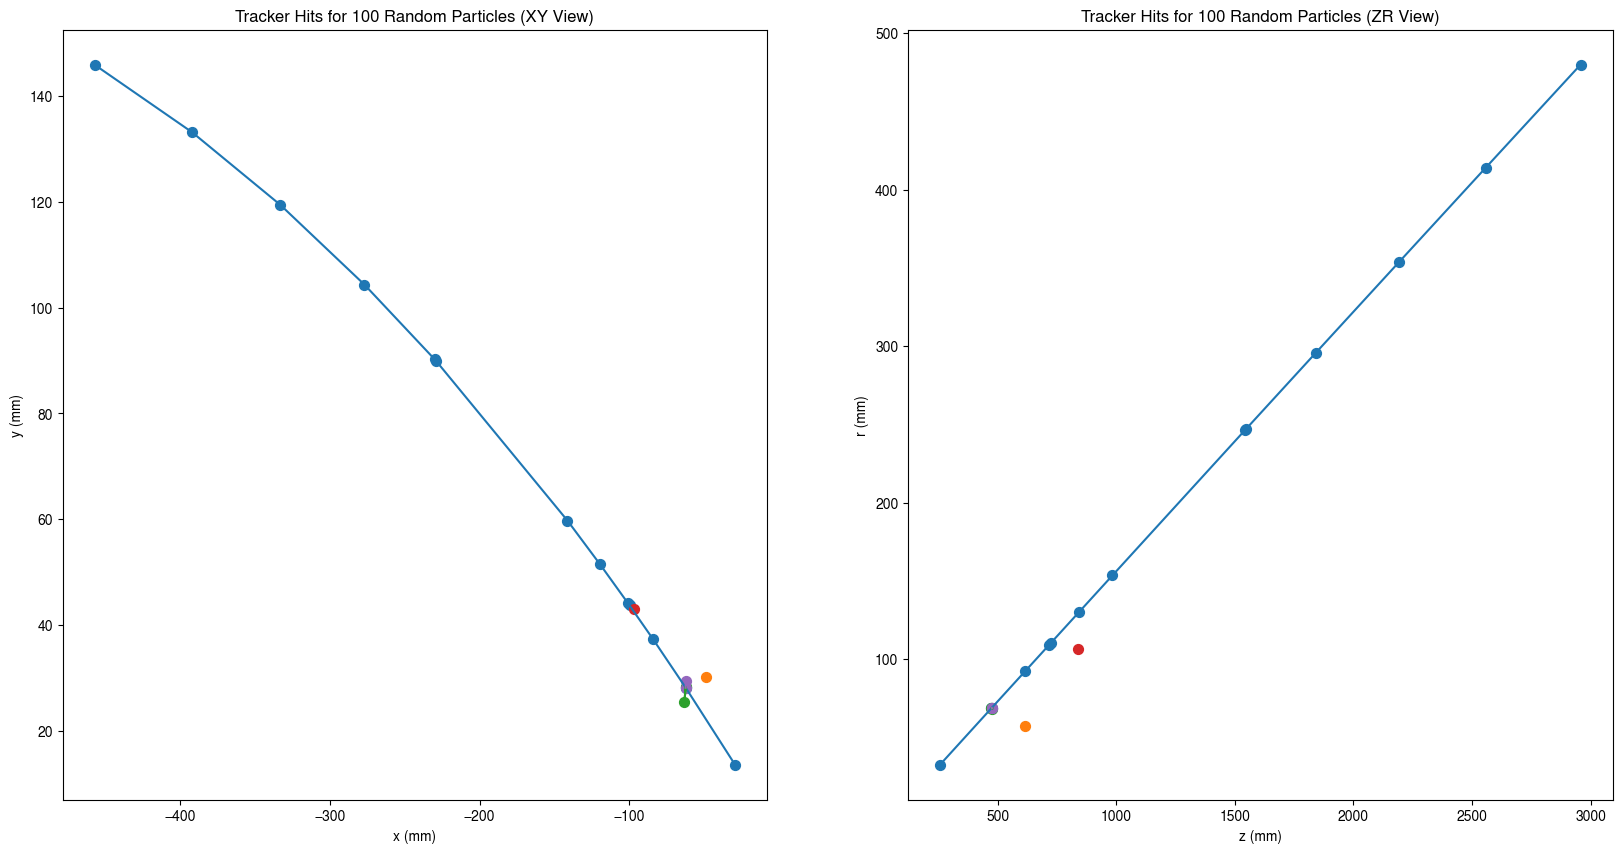

In [71]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot the hits, colored by particle id
for particle_id in tracker_reco_particles.index:
    particle_hits = hits[hits['particle_id'] == particle_id]
    
    # XY plot
    ax1.plot(particle_hits.x, particle_hits.y)
    ax1.scatter(particle_hits.x, particle_hits.y, s=50)
    
    # ZR plot
    ax2.plot(particle_hits.z, particle_hits.r)
    ax2.scatter(particle_hits.z, particle_hits.r, s=50)

ax1.set_xlabel('x (mm)')
ax1.set_ylabel('y (mm)')
ax1.set_title('Tracker Hits for 100 Random Particles (XY View)')

ax2.set_xlabel('z (mm)')
ax2.set_ylabel('r (mm)')
ax2.set_title('Tracker Hits for 100 Random Particles (ZR View)')

plt.show()